In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, classification_report

In [3]:
# Load dataset
df = pd.read_csv("Pima_diabetes.csv")  # Replace with your actual dataset path

In [5]:
# Split features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']


In [6]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
 #Scale features (important for logistic regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [9]:
# Predict
y_pred = model.predict(X_test)


In [10]:
# Metrics
cm = confusion_matrix(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [12]:
print("Confusion Matrix:\n", cm)
print("F1 Score:", f1)

Confusion Matrix:
 [[79 20]
 [18 37]]
F1 Score: 0.6607142857142857


In [21]:
# Normalized confusion matrix (percentages)
#normalizes the matrix so you can see how accurate each class is 
#in percentage form (way more insightful than just raw counts)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100



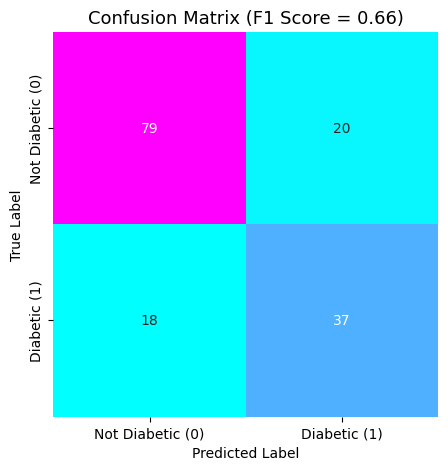

In [17]:
# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='cool', cbar=False, square=True,
            xticklabels=['Not Diabetic (0)', 'Diabetic (1)'],
            yticklabels=['Not Diabetic (0)', 'Diabetic (1)'])
plt.title(f'Confusion Matrix (F1 Score = {f1:.2f})', fontsize=13)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [15]:
# Print classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154

